In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [6]:
p = 5
cd = "KS"
files = {
    # "BASE": "BASE/imputation_results_BASE_30.csv",
    #"KS": "KS/imputation_results_KS_5.csv",
    # 'PH': f"PH/imputation_results_PH_{p}.csv",
    cd: f"{cd}/imputation_results_{cd}_{p}.csv",
}

df = pd.concat(
    [pd.read_csv(path).assign(dataset=dataset) for dataset, path in files.items()],
    ignore_index=True
)

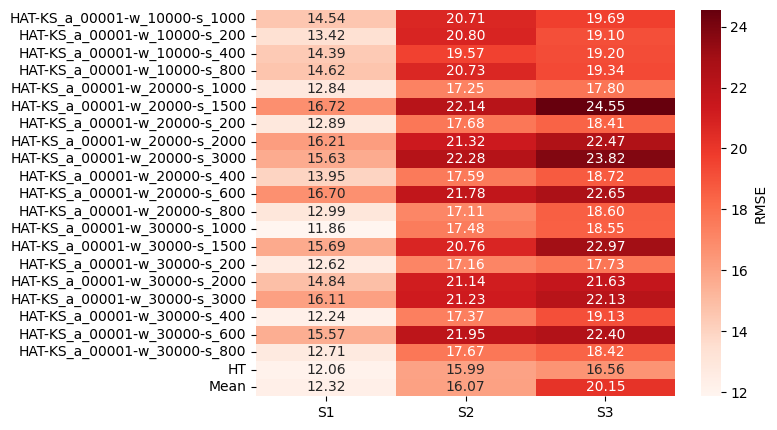

In [7]:
pivot = df.pivot_table(index='imputer', columns='mechanism', values='mean_rmse', aggfunc='mean')
plt.figure(figsize=(8, 0.2*len(pivot)))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='Reds', cbar_kws={'label': 'RMSE'})
plt.ylabel('')
plt.xlabel('')
plt.tight_layout()
plt.savefig(f'{cd}/heatmap_rmse_{cd}_{p}.png', dpi=300)
plt.show()

In [8]:
import re

# Definir padrões
method_patterns = {
    "HAT_KS": r"^HAT-KS",
    "HAT_PH": r"^HAT-PH",
    "HAT_ADWIN": r"^HAT-ADWIN",
    "MEAN": r"^Mean",
    "HT": r"^HT"
}

def classify_method(name):
    for label, pattern in method_patterns.items():
        if re.match(pattern, name):
            return label
    return "OTHER"

df["method_group"] = df["imputer"].apply(classify_method)

df["rank"] = (
    df.groupby(["mechanism", "method_group"])["mean_rmse"]
      .rank(method="dense", ascending=True)
)

ranking = (
    df.sort_values(["mechanism", "method_group", "rank"])
      [["mechanism", "method_group", "imputer", "mean_rmse", "rank"]]
      .reset_index(drop=True)
)

t = 3
tops = (
    df[df["rank"] <= t]
    .sort_values(["mechanism", "method_group", "rank"])
    [["mechanism", "method_group", "imputer", "mean_rmse", "rank"]]
    .reset_index(drop=True)
)

tops = tops.drop_duplicates(
    subset=["mechanism", "method_group", "imputer", "mean_rmse", "rank"]
).reset_index(drop=True)

print(f"\nTop {t} por mechanism e tipo de método:\n")
print(tops.to_string(index=False))


Top 3 por mechanism e tipo de método:

mechanism method_group                       imputer  mean_rmse  rank
       S1       HAT_KS HAT-KS_a_00001-w_30000-s_1000      11.86   1.0
       S1       HAT_KS  HAT-KS_a_00001-w_30000-s_400      12.24   2.0
       S1       HAT_KS  HAT-KS_a_00001-w_30000-s_200      12.62   3.0
       S1           HT                            HT      12.06   1.0
       S1         MEAN                          Mean      12.32   1.0
       S2       HAT_KS  HAT-KS_a_00001-w_20000-s_800      17.11   1.0
       S2       HAT_KS  HAT-KS_a_00001-w_30000-s_200      17.16   2.0
       S2       HAT_KS HAT-KS_a_00001-w_20000-s_1000      17.25   3.0
       S2           HT                            HT      15.99   1.0
       S2         MEAN                          Mean      16.07   1.0
       S3       HAT_KS  HAT-KS_a_00001-w_30000-s_200      17.73   1.0
       S3       HAT_KS HAT-KS_a_00001-w_20000-s_1000      17.80   2.0
       S3       HAT_KS  HAT-KS_a_00001-w_20000-s_2

In [9]:
tops.to_csv(f"{cd}/top{t}_{p}p_{cd}.csv", index=False)

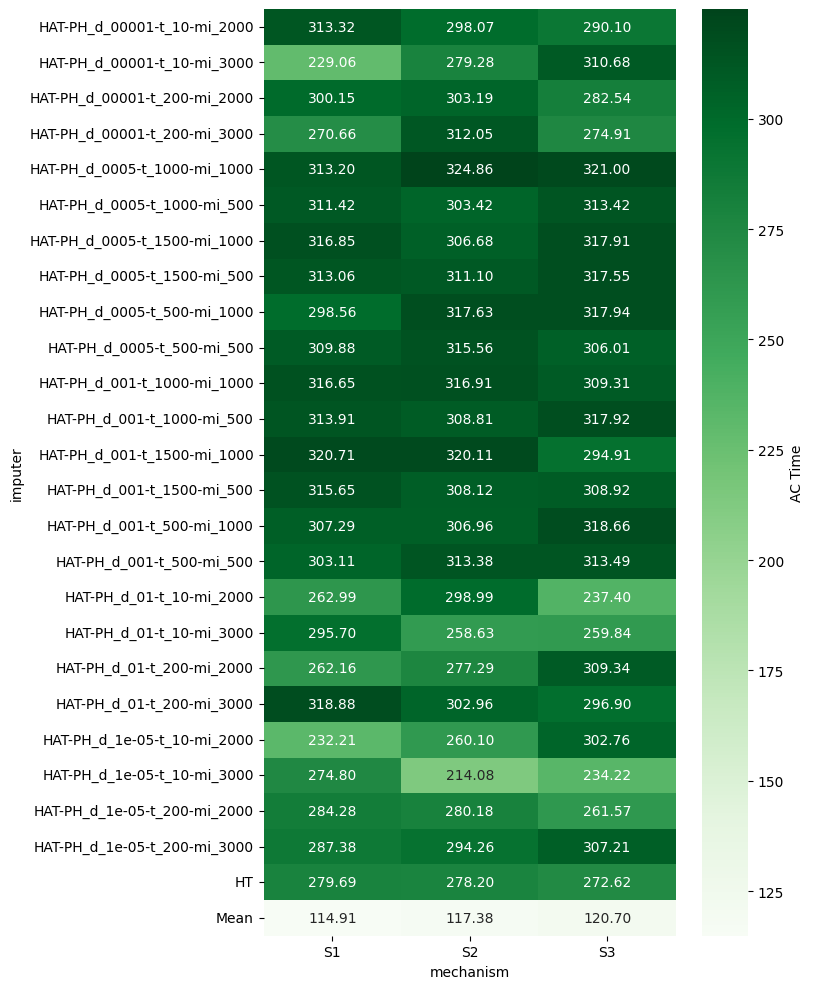

In [5]:
pivot = df.pivot_table(index='imputer', columns='mechanism', values='ac_time', aggfunc='mean')
plt.figure(figsize=(8, 10))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='Greens', cbar_kws={'label': 'AC Time'})
plt.ylabel('imputer')
plt.xlabel('mechanism')
plt.tight_layout()
plt.show()

In [9]:
files = {
    # "BASE": "BASE/imputation_results_by_patient_BASE_30.csv",
    "KS": "KS/imputation_results_by_patient_KS_5.csv",
}

df = pd.concat(
    [pd.read_csv(path).assign(dataset=dataset) for dataset, path in files.items()],
    ignore_index=True
)

mechanism_order = sorted(
    df["mechanism"].dropna().unique(),
    key=lambda m: int("".join(ch for ch in str(m) if ch.isdigit()) or 10**9)
)

df["mechanism"] = pd.Categorical(df["mechanism"], categories=mechanism_order, ordered=True)
df = df.sort_values(["mechanism", "patient", "dataset", "imputer"]).reset_index(drop=True)

# patients_in_both = (
#     df.groupby("patient")["dataset"]
#         .nunique()
#         .loc[lambda s: s == 2]
#         .index
# )

# df = df[df["patient"].isin(patients_in_both)].copy()

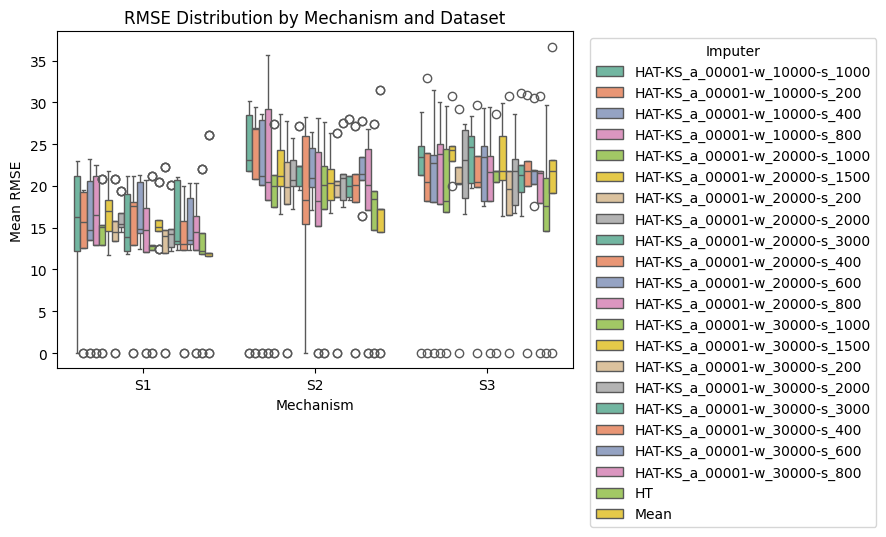

In [10]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="mechanism", y="mean_rmse", hue="imputer", palette="Set2")

plt.title("RMSE Distribution by Mechanism and Dataset")
plt.xlabel("Mechanism")
plt.ylabel("Mean RMSE")
plt.legend(title="Imputer", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()